<a href="https://colab.research.google.com/github/robertccruz13-ship-it/sds-510-robert-cruz/blob/main/california_housing_5_3_robert_cruz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import sklearn
from sklearn.datasets import fetch_california_housing
california_housing = fetch_california_housing(as_frame=True)

In [3]:
california_housing.frame['AveRooms'].describe()

,AveRooms
count,20640.000000
mean,5.429000
std,2.474173
min,0.846154
25%,4.440716
50%,5.229129
75%,6.052381
max,141.909091


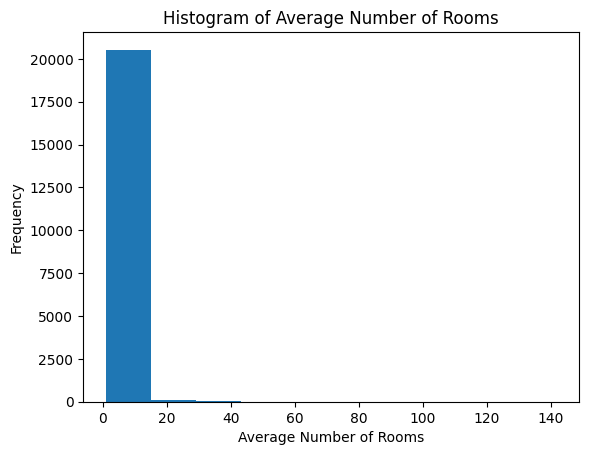

In [5]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(california_housing.frame['AveRooms'])
plt.title("Histogram of Average Number of Rooms")
plt.xlabel("Average Number of Rooms")
plt.ylabel("Frequency")
plt.show()

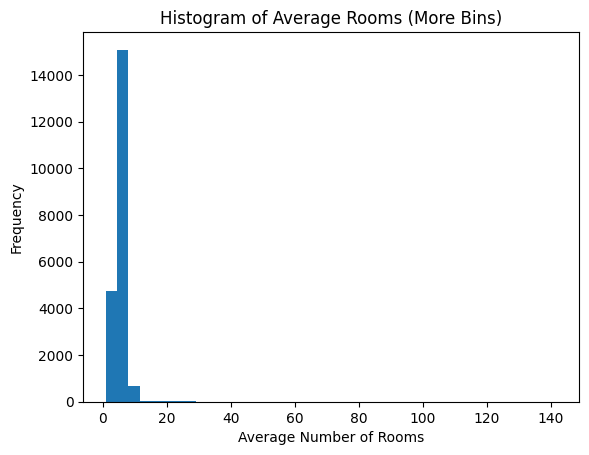

In [7]:
plt.figure()
plt.hist(california_housing.frame['AveRooms'], bins=40)
plt.title("Histogram of Average Rooms (More Bins)")
plt.xlabel("Average Number of Rooms")
plt.ylabel("Frequency")
plt.show()

In [9]:
california_housing.frame['RoomCategory'] = pd.cut(
    california_housing.frame['AveRooms'],
    bins=[0,4,6,8,20],
    labels=["Small", "Medium", "Large", "Very Large"]
)

california_housing.frame['RoomCategory'].head()

,RoomCategory
0,Large
1,Large
2,Very Large
3,Medium
4,Large


In [11]:
freq = california_housing.frame['RoomCategory'].value_counts()
freq

,count
RoomCategory,
Medium,12344
Large,4684
Small,2889
Very Large,654


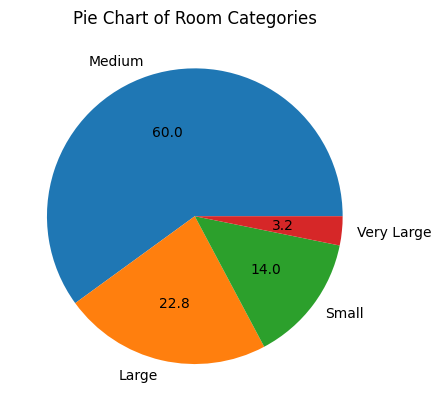

In [12]:
from enum import auto
plt.figure()
freq.plot(kind='pie', autopct='%1.1f')
plt.title("Pie Chart of Room Categories")
plt.ylabel("")
plt.show()

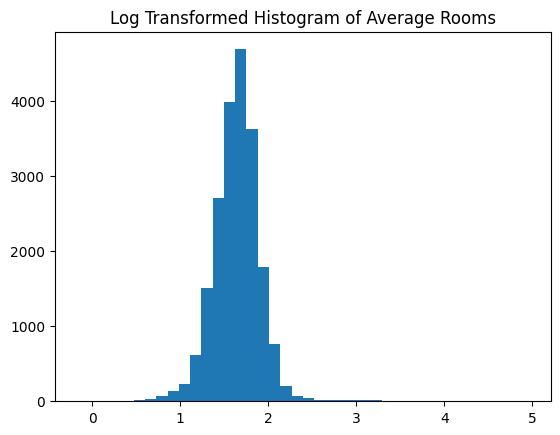

In [14]:
import numpy as np

california_housing.frame['Log_AveRooms'] = np.log(california_housing.frame['AveRooms'])

plt.figure()
plt.hist(california_housing.frame['Log_AveRooms'], bins=40)
plt.title("Log Transformed Histogram of Average Rooms")
plt.show()

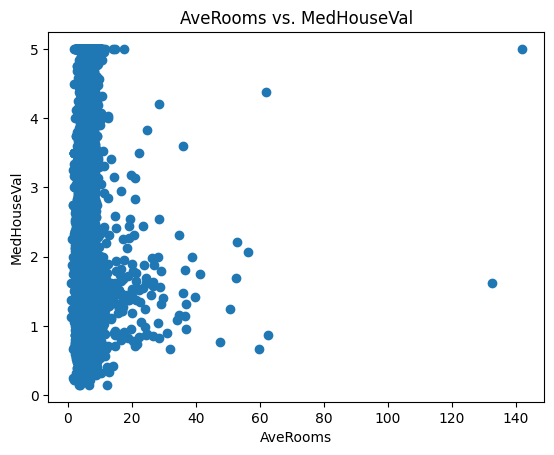

In [16]:
plt.figure()
plt.scatter(california_housing.frame['AveRooms'], california_housing.frame['MedHouseVal'])
plt.title('AveRooms vs. MedHouseVal')
plt.xlabel('AveRooms')
plt.ylabel('MedHouseVal')
plt.show()

In [18]:
california_housing.frame[['AveRooms', 'MedHouseVal']].corr()

,AveRooms,MedHouseVal
AveRooms,1.000000,0.151948
MedHouseVal,0.151948,1.000000


In [20]:
from scipy.stats import pearsonr

pearsonr(california_housing.frame['AveRooms'], california_housing.frame['MedHouseVal'])

PearsonRResult(statistic=np.float64(0.15194828974145785), pvalue=np.float64(7.569242134483068e-107))

In this analysis, I examined the vairable Average Rooms from the California Housing dataset. The distribution of average rooms was right skewed, with most of the values concentrated between 4 and 6 rooms. After applying a transformation, the distribution appeared more normally distributed. When analyzing the realationship between the average rooms and median house value, I found a weak positive correlation. After renovibg extreme outliers, the relationship became clearer, though still modest. The correlation test showed that the relationship was statistically significant. Overall, while average rooms has some relatonship with housiing prices, it is not a strong predictor by itself.  